# Nowcasting lagged private markets returns

### `private_assets_frequency.nowcast` — tutorial

Private markets indices are published with a lag of roughly a quarter. That means
there is always a stretch of time in which a quarter has **closed** — the economic
return exists — but has **not been published**. Meanwhile the public markets that
drive most of that return are observable in real time.

This sub-package estimates those missing quarters.

---

### The situation this is built for

> It is **7 October 2026**. The Q2-2026 private equity index return has not been
> published. Q3-2026 has just closed. Public market data runs to today.

Two quarters are missing, and both are nowcastable:

| Quarter | Reference period ended | Published? | Horizon |
| --- | --- | --- | --- |
| 2026Q1 | 31 Mar 2026 | ✅ yes (9 Jul 2026) | — |
| **2026Q2** | 30 Jun 2026 | ❌ not yet (due 8 Oct) | **h = 1** |
| **2026Q3** | 30 Sep 2026 | ❌ not yet (due Jan 2027) | **h = 2** |
| 2026Q4 | *still open* | — | excluded |

### What you'll learn

1. **Quickstart** — five lines from a reported series to two nowcasts with intervals
2. **The information set** — the one concept everything else depends on
3. **Vintages** — why "which value did we know at the time" is not a detail
4. **The four models** — and why the simplest one is the benchmark, not a baseline
5. **Prediction intervals** — and why they widen with horizon
6. **The evaluation harness** — how to read its report honestly
7. **Signatures** — what the challenger model actually looks at
8. **Pipeline integration** — feeding provisional quarters downstream safely
9. **Pitfalls** — the mistakes this package is designed to make hard

### What this is *not*

It does not predict the future. Every quarter it estimates has **already
happened**; the information simply has not been published yet. That is what makes
the problem tractable — and what makes a leaked future observation so damaging,
since the answer is sitting right there in the data you must not look at.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v: .4f}")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

AS_OF = pd.Timestamp("2026-10-07")   # "today", throughout this notebook
print("as_of =", AS_OF.date())

Matplotlib is building the font cache; this may take a moment.


as_of = 2026-10-07


## 0. Synthetic data, so this notebook runs anywhere

We generate a private equity index that behaves the way real ones do. Writing the
data-generating process out explicitly is worth the space, because it is the
mental model the rest of the notebook assumes:

```
daily public factor returns          ->  F_Q = Π(1+r) − 1       (quarterly compound)
true economic return                 ->  r_Q = α + β·F_Q + ε_Q
reported (appraisal-smoothed) return ->  s_Q = (1−λ)·r_Q + λ·s_{Q−1}
```

The last line is the whole problem. Appraisal smoothing is a **low-pass filter**:
the reported series is a lagged, damped version of the economic one. With
`λ = 0.6`, 60 % of each reported quarter is just last quarter's report carried
forward.

We also generate a **vintage table** — one row per *release* of each quarter,
including revisions — because a real index is not published once. The first print
is based on a partial set of fund NAVs and gets revised as late reporters arrive.

In [2]:
N_QUARTERS = 103          # 2001Q1 .. 2026Q3
LAMBDA = 0.60             # appraisal smoothing: 60% weight on the previous report
BETA = 1.10               # leveraged equity beta
ALPHA = 0.005             # 50bp per quarter
SIGMA_EPS = 0.025         # idiosyncratic vol of the TRUE return
PUBLICATION_LAG_DAYS = 100
REVISION_SD = 0.004       # first print differs from the final value by ~40bp


def make_index(path_dependent: bool = False, seed: int = 20261011):
    """A smoothed private markets index with a vintage table.

    Parameters
    ----------
    path_dependent
        If True, the appraiser marks against the *average* public level over the
        quarter rather than its closing return. Used later to show when the
        signature model earns its keep.
    """
    rng = np.random.default_rng(seed)
    q0 = pd.Period("2001Q1", freq="Q")
    quarters = pd.period_range(q0, periods=N_QUARTERS, freq="Q")

    # Daily public factor, running two quarters past the last reported quarter
    days = pd.bdate_range(q0.start_time, (quarters[-1] + 2).end_time)
    daily = pd.DataFrame(
        {"equity_market": rng.standard_normal(len(days)) * 0.16 / np.sqrt(252)},
        index=days,
    )

    # Quarterly compound of the daily factor: Π(1+r) − 1
    log1p = np.log1p(daily)
    by_q = pd.PeriodIndex(daily.index, freq="Q")
    factors_q = np.expm1(log1p.groupby(by_q).sum())
    factors_q.index = pd.PeriodIndex(factors_q.index, freq="Q")

    if path_dependent:
        # The appraiser tracks the average level over the quarter — a genuinely
        # path-dependent mark that the quarter-end return cannot capture.
        signal = {}
        for q, block in log1p.groupby(by_q):
            level = block["equity_market"].cumsum().to_numpy()
            u = np.arange(1, len(level) + 1) / len(level)
            padded = np.concatenate([[0.0], level])
            signal[q] = np.trapz(padded, x=np.concatenate([[0.0], u]))
        drive = pd.Series(np.expm1(pd.Series(signal)), name="equity_market")
        drive.index = pd.PeriodIndex(drive.index, freq="Q")
        drive = drive.loc[quarters]
        eps_sd = 0.012          # the path statistic is damped, so scale noise down
    else:
        drive = factors_q.loc[quarters, "equity_market"]
        eps_sd = SIGMA_EPS

    true_returns = ALPHA + BETA * drive.to_numpy() + rng.normal(0, eps_sd, N_QUARTERS)

    # Appraisal smoothing, started in its own steady state
    reported = np.empty(N_QUARTERS)
    reported[0] = true_returns[0]
    for t in range(1, N_QUARTERS):
        reported[t] = (1 - LAMBDA) * true_returns[t] + LAMBDA * reported[t - 1]

    # Vintage table: three releases per quarter, converging on the final value
    rows = []
    for i, q in enumerate(quarters):
        base = q.end_time.normalize() + pd.Timedelta(days=PUBLICATION_LAG_DAYS)
        for k in range(3):
            noise = 0.0 if k == 2 else REVISION_SD * (0.5 ** k) * rng.standard_normal()
            rows.append({
                "quarter": q,
                "release_date": base + pd.Timedelta(days=91 * k),
                "value": reported[i] + noise,
            })

    return {
        "reported": pd.Series(reported, index=quarters, name="pe_index"),
        "true_returns": pd.Series(true_returns, index=quarters, name="true_return"),
        "daily_factors": daily,
        "quarterly_factors": factors_q,
        "vintages": pd.DataFrame(rows),
    }


data = make_index()
print(f"reported quarters : {data['reported'].index[0]} .. {data['reported'].index[-1]}")
print(f"daily factors     : {data['daily_factors'].index[0].date()} .. "
      f"{data['daily_factors'].index[-1].date()}")
print(f"vintage rows      : {len(data['vintages'])}  ({len(data['vintages']) // N_QUARTERS} per quarter)")

reported quarters : 2001Q1 .. 2026Q3
daily factors     : 2001-01-01 .. 2027-03-31
vintage rows      : 309  (3 per quarter)


Here is the smoothing problem, drawn. The reported series is visibly a damped,
lagged copy of the economic one — its volatility is roughly **half**.

annualised vol of true return     : 17.7%
annualised vol of reported return : 9.4%
ratio                             : 0.53


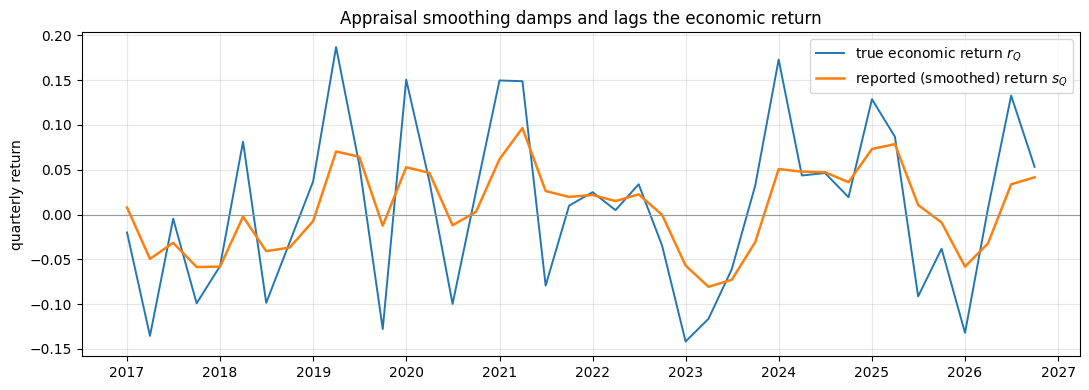

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
window = slice(-40, None)
ax.plot(data["true_returns"].index[window].to_timestamp(how="end"),
        data["true_returns"].iloc[window], lw=1.4, label="true economic return $r_Q$")
ax.plot(data["reported"].index[window].to_timestamp(how="end"),
        data["reported"].iloc[window], lw=1.8, label="reported (smoothed) return $s_Q$")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_title("Appraisal smoothing damps and lags the economic return")
ax.set_ylabel("quarterly return")
ax.legend()
plt.tight_layout()

print(f"annualised vol of true return     : {data['true_returns'].std() * 2:.1%}")
print(f"annualised vol of reported return : {data['reported'].std() * 2:.1%}")
print(f"ratio                             : {data['reported'].std() / data['true_returns'].std():.2f}")

## 1. Quickstart

Three steps: say what you knew and when, fit a model, predict the missing
quarters.

In [4]:
from private_assets_frequency.nowcast import (
    SmoothingRegressionNowcaster,
    build_information_set,
)

# 1. What was knowable on 7 October 2026
info = build_information_set(
    reported=data["reported"],
    public_factors=data["daily_factors"],
    as_of=AS_OF,
    vintages=data["vintages"],
)

# 2. Fit — on the information set, never on raw data
model = SmoothingRegressionNowcaster().fit(info)

# 3. Nowcast every closed-but-unpublished quarter
results = model.predict(info, info.unpublished_quarters(),
                        rng=np.random.default_rng(0))

for r in results:
    lo, hi = r.interval_80
    print(f"{r.quarter}  h={r.horizon}  nowcast {r.point:+.2%}   "
          f"80% interval [{lo:+.2%}, {hi:+.2%}]")

2026Q2  h=1  nowcast +4.68%   80% interval [+3.65%, +6.41%]
2026Q3  h=2  nowcast +4.77%   80% interval [+3.54%, +6.72%]


That is the whole API surface for a basic nowcast. Everything below is about
knowing whether to believe it.

Note what the module worked out for itself: **which** quarters were missing, and
what horizon each sat at. You never told it.

In [5]:
print(info)
print()
print("last published quarter :", info.last_published_quarter)
print("unpublished quarters   :", [str(q) for q in info.unpublished_quarters()])
print("horizons               :", {str(q): info.horizon_of(q) for q in info.unpublished_quarters()})

InformationSet(as_of=2026-10-07, mode='vintage', n_published=101, last_published=2026Q1, unpublished=['2026Q2', '2026Q3'], factors=['equity_market'])

last published quarter : 2026Q1
unpublished quarters   : ['2026Q2', '2026Q3']
horizons               : {'2026Q2': 1, '2026Q3': 2}


## 2. The information set — the one concept that matters

Every nowcast is made **as of a date**. The information set at that date is
*exactly*:

- public factor observations with timestamp ≤ `as_of`
- reported index values whose **publication date** ≤ `as_of`
- optional early-signal observations with timestamp ≤ `as_of`

The second bullet is the whole game. It is **not** "whose reference quarter ended
before `as_of`". Q2-2026 ended on 30 June but is not published until October, so
on 7 October it is closed, unpublished, and nowcastable.

Models never receive raw data. They receive an `InformationSet`, which truncates
everything at construction and stores copies — so there is no code path by which
a model can reach an observation it should not have seen.

In [6]:
# What a real index release schedule looks like around our as_of
v = data["vintages"]
recent = v[v["quarter"].isin([pd.Period(q, freq="Q") for q in ("2026Q1", "2026Q2", "2026Q3")])]
recent = recent.assign(visible_at_as_of=recent["release_date"] <= AS_OF)
print(recent.to_string(index=False))
print()
print("=> at as_of only the 2026-07-09 print of 2026Q1 has landed,")
print("   so 2026Q1 is the last published quarter.")

quarter release_date   value  visible_at_as_of
 2026Q1   2026-07-09 -0.0405              True
 2026Q1   2026-10-08 -0.0347             False
 2026Q1   2027-01-07 -0.0323             False
 2026Q2   2026-10-08  0.0348             False
 2026Q2   2027-01-07  0.0331             False
 2026Q2   2027-04-08  0.0337             False
 2026Q3   2027-01-08  0.0381             False
 2026Q3   2027-04-09  0.0430             False
 2026Q3   2027-07-09  0.0415             False

=> at as_of only the 2026-07-09 print of 2026Q1 has landed,
   so 2026Q1 is the last published quarter.


In [7]:
# The information set holds nothing dated after as_of. Not "almost nothing".
print("last factor observation :", info.public_factors.index[-1].date(), " (as_of:", AS_OF.date(), ")")
print("all factor rows <= as_of:", bool((info.public_factors.index <= AS_OF).all()))
print("all vintage rows <= as_of:", bool((info.vintages["release_date"] <= AS_OF).all()))
print()
print("published quarters in the information set:", info.n_published)
print("2026Q2 present?", pd.Period("2026Q2", freq="Q") in info.reported.index)

last factor observation : 2026-10-07  (as_of: 2026-10-07 )
all factor rows <= as_of: True
all vintage rows <= as_of: True

published quarters in the information set: 101
2026Q2 present? False


### A quarter can be closed, have complete factor data, and still be unpublished

That is the gap the module exploits. Q3-2026 closed on 30 September, so **all** of
its public factor data is in hand — but its index value is months away.

The open quarter Q4-2026 is different: only a week of it has happened, so its
factor aggregate is a partial-quarter figure that is not comparable to the
full-quarter aggregates the models train on. It is excluded by default.

In [8]:
coverage = pd.DataFrame({
    "factor_data_complete": info.factor_quarter_complete,
    "coverage_of_quarter": info.factor_quarter_coverage,
    "index_published": [q in info.reported.index for q in info.factor_quarter_complete.index],
}).tail(5)
print(coverage.to_string())
print()
try:
    info.factor_row("2026Q4")
except ValueError as exc:
    print("factor_row('2026Q4') ->", str(exc)[:150], "...")

        factor_data_complete  coverage_of_quarter  index_published
2025Q4                  True               0.9891             True
2026Q1                  True               0.9889             True
2026Q2                  True               0.9890            False
2026Q3                  True               0.9891            False
2026Q4                 False               0.0652            False

factor_row('2026Q4') -> factor data for 2026Q4 is incomplete at as_of=2026-10-07 (coverage 0.07); pass require_complete=False to use the partial-quarter compound. ...


### Proving there is no leakage

This is the package's acceptance criterion, and you can check it yourself: shift
**every** post-`as_of` observation by a large amount and the nowcast must not move
a single bit.

In [9]:
def nowcast_points(public_factors, vintages):
    """Fit and predict from scratch, returning just the point nowcasts."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        i = build_information_set(data["reported"], public_factors, AS_OF, vintages=vintages)
        m = SmoothingRegressionNowcaster().fit(i)
        return [r.point for r in m.predict(i, i.unpublished_quarters(),
                                          rng=np.random.default_rng(0))]

baseline = nowcast_points(data["daily_factors"], data["vintages"])

# Sabotage everything dated after as_of
wrecked_factors = data["daily_factors"].copy()
wrecked_factors.loc[wrecked_factors.index > AS_OF] += 0.25      # +25% a day!
wrecked_vintages = data["vintages"].copy()
wrecked_vintages.loc[wrecked_vintages["release_date"] > AS_OF, "value"] += 0.50

sabotaged = nowcast_points(wrecked_factors, wrecked_vintages)

print("baseline :", [f"{p:+.10f}" for p in baseline])
print("sabotaged:", [f"{p:+.10f}" for p in sabotaged])
print()
print("bit-for-bit identical:", baseline == sabotaged)

baseline : ['+0.0468092877', '+0.0477437747']
sabotaged: ['+0.0468092877', '+0.0477437747']

bit-for-bit identical: True


## 3. Vintages — "which value did we know at the time?"

A private markets index print is not a fact, it is an estimate that gets revised
for several quarters as late-reporting funds arrive. There are two data modes.

**Vintage mode** (preferred). You supply a long frame
`[quarter, release_date, value]`, one row per release. The value known at `as_of`
is the latest release at or before it.

**Lag-rule mode** (fallback). You supply only the final revised series plus a
publication lag. The module warns, because this is *pseudo-real-time*: it uses
revised values as if they had been available at first release.

The warning is not boilerplate. Revisions are mean-reverting as late reporters
arrive, so the revised series is **systematically easier to predict** than the
first print. Validation in lag-rule mode flatters every model.

In [10]:
q1 = pd.Period("2026Q1", freq="Q")

# What we knew about 2026Q1 at three different dates
for when in ("2026-07-10", "2026-10-09", "2027-02-01"):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        snap = build_information_set(data["reported"], data["daily_factors"],
                                     pd.Timestamp(when), vintages=data["vintages"])
    print(f"as_of {when}:  2026Q1 = {snap.reported[q1]:+.4%}   "
          f"(release {snap.release_dates[q1].date()}, revision #{snap.n_releases[q1]})")

print(f"\nfinal revised value:        {data['reported'][q1]:+.4%}")
print("=> in vintage mode the LAGGED PREDICTOR carries the vintage in force,")
print("   not a number that did not exist yet.")

as_of 2026-07-10:  2026Q1 = -4.0489%   (release 2026-07-09, revision #1)
as_of 2026-10-09:  2026Q1 = -3.4657%   (release 2026-10-08, revision #2)
as_of 2027-02-01:  2026Q1 = -3.2275%   (release 2027-01-07, revision #3)

final revised value:        -3.2275%
=> in vintage mode the LAGGED PREDICTOR carries the vintage in force,
   not a number that did not exist yet.


In [11]:
from private_assets_frequency.nowcast import NowcastDataModeWarning

# Lag-rule mode: no vintages, so the module tells you what you are giving up
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lag_info = build_information_set(data["reported"], data["daily_factors"], AS_OF)

for w in caught:
    if issubclass(w.category, NowcastDataModeWarning):
        print("WARNING:", " ".join(str(w.message).split())[:420], "...")

print()
print("lag-rule mode last published:", lag_info.last_published_quarter,
      " (same answer, but from the revised series)")
print("value used for 2026Q1       :", f"{lag_info.reported[q1]:+.4%}",
      "<- the FINAL value, which in real time did not exist")


lag-rule mode last published: 2026Q1  (same answer, but from the revised series)
value used for 2026Q1       : -3.2275% <- the FINAL value, which in real time did not exist


`evaluation_target` controls which realisation a nowcast is scored against:
`'first_print'` (the default in vintage mode) or `'latest'`. Scoring against the
latest revision answers a legitimate but *different* question — "how close is the
nowcast to the truth as we now understand it" — and it will always look better.

## 4. The four models

| Model | What it is | When to use it |
| --- | --- | --- |
| `NaiveCarryForward` | Last published value, carried forward | Always — as the bar to clear |
| `SmoothingRegressionNowcaster` | The reduced form of the library's AR(1)/Rudin models | **The default and the benchmark** |
| `StructuralSmoothingNowcaster` | Reuses a fitted desmoothing model's λ, α, β | When Stage 1 has already committed to parameters |
| `SignatureNowcaster` | Path-signature features of the public market path | When the mark depends on the *path*, not just the close |

### Model 0 — the baseline is not a strawman

Reported private markets returns are heavily autocorrelated **by construction** —
appraisal smoothing *is* an AR(1) filter. So carrying the last print forward is a
genuinely strong predictor, and a factor model that cannot beat it has
demonstrated nothing.

In [12]:
from private_assets_frequency.nowcast import NaiveCarryForward

naive = NaiveCarryForward().fit(info)
naive_results = naive.predict(info, info.unpublished_quarters(),
                             rng=np.random.default_rng(0))

print("last published value:", f"{info.reported.iloc[-1]:+.4%}")
for r in naive_results:
    print(f"  {r.quarter} h={r.horizon}: {r.point:+.4%}  <- unchanged, by construction")

print(f"\nautocorrelation of the reported series: "
      f"{info.reported.autocorr():.3f}  <- why this baseline is hard to beat")

last published value: -4.0489%
  2026Q2 h=1: -4.0489%  <- unchanged, by construction
  2026Q3 h=2: -4.0489%  <- unchanged, by construction

autocorrelation of the reported series: 0.647  <- why this baseline is hard to beat


### Model 1 — the smoothing regression, and why it *is* the benchmark

$$ s_Q = a + \sum_k b_k F_{k,Q} + \sum_{j=1}^{q} c_j\, s_{Q-j} + e_Q $$

This is not an arbitrary regression. It is the **reduced form of the library's own
Stage-1 desmoothing models**. Substituting the factor model
$r_Q = \alpha + \beta F_Q + \varepsilon_Q$ into the AR(1) appraisal filter
$s_Q = (1-\lambda) r_Q + \lambda s_{Q-1}$:

$$ s_Q = \underbrace{(1-\lambda)\alpha}_{a} + \underbrace{(1-\lambda)\beta}_{b} F_Q
       + \underbrace{\lambda}_{c_1} s_{Q-1} + \underbrace{(1-\lambda)\varepsilon_Q}_{e_Q} $$

So one OLS on observables recovers $b = (1-\lambda)\beta$ and $c_1 = \lambda$
*without ever estimating $\lambda$ separately*. Let's check it against the
parameters we generated the data with.

In [13]:
coef = model.coefficients
structural = model.structural_params

print("REDUCED-FORM COEFFICIENTS")
print(f"  a  = {coef['const']:+.4f}")
print(f"  b  = {coef['equity_market']:+.4f}   target (1-λ)β = {(1 - LAMBDA) * BETA:.4f}")
print(f"  c₁ = {coef['s_lag1']:+.4f}   target λ      = {LAMBDA:.4f}")
print()
print("UNWOUND STRUCTURAL PARAMETERS   (β = b/θ₀, θ₀ = 1 − Σc)")
print(f"  λ implied = {structural['lambda_implied']:.4f}   true λ = {LAMBDA}")
print(f"  β         = {structural['beta']['equity_market']:.4f}   true β = {BETA}")
print(f"  α         = {structural['alpha']:+.4f}   true α = {ALPHA}")
print()
print(f"  R²        = {model.fit_diagnostics['r_squared']:.4f}")
print(f"  σ_e       = {model.sigma:.4f}   target (1-λ)σ_ε = {(1 - LAMBDA) * SIGMA_EPS:.4f}")

REDUCED-FORM COEFFICIENTS
  a  = +0.0011
  b  = +0.4469   target (1-λ)β = 0.4400
  c₁ = +0.6075   target λ      = 0.6000

UNWOUND STRUCTURAL PARAMETERS   (β = b/θ₀, θ₀ = 1 − Σc)
  λ implied = 0.6075   true λ = 0.6
  β         = 1.1388   true β = 1.1
  α         = +0.0028   true α = 0.005

  R²        = 0.9560
  σ_e       = 0.0098   target (1-λ)σ_ε = 0.0100


Both the smoothing parameter and the factor loading are recovered from a single
OLS on observable quantities. That is why this model is the thing to beat rather
than a baseline to dismiss.

### Model 2 — reuse a fitted desmoothing model

If Stage 1 of the pipeline has already committed to a λ and a β for this strategy,
the nowcast should be consistent with them rather than quietly implying different
ones. `StructuralSmoothingNowcaster` takes a `DesmoothedResult` and evaluates the
same forecast with *those* parameters — nothing is re-estimated.

In [14]:
from private_assets_frequency.desmoothing.rudin_reparam import RudinReparamSmoothing
from private_assets_frequency.nowcast import StructuralSmoothingNowcaster

# Fit Stage 1 INSIDE the information set (so the parameters are not leaky)
published = pd.PeriodIndex(info.reported.index, freq="Q")
obs = info.reported.copy()
obs.index = published.to_timestamp(how="end")
fac = info.factors_quarterly.loc[published].copy()
fac.index = obs.index

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    desmoothed = RudinReparamSmoothing(n_lags=1).fit(obs, fac, {})
    structural_model = StructuralSmoothingNowcaster(desmoothed=desmoothed).fit(info)
    structural_results = structural_model.predict(
        info, info.unpublished_quarters(), rng=np.random.default_rng(0))

diag = structural_model.fit_diagnostics
print("borrowed from :", diag["source_method"])
print("convention    :", diag["fitted_convention"], "->", diag["lambda_conversion"]["formula"])
print("λ (quarterly) :", f"{diag['lambda_quarterly']:.4f}")
print()
print("structural vs smoothing-regression point nowcasts:")
for a, b in zip(structural_results, results):
    print(f"  {a.quarter}: {a.point:+.8f}  vs  {b.point:+.8f}   diff {a.point - b.point:+.1e}")

borrowed from : rudin_reparam
convention    : quarterly -> identity (model fitted at quarterly frequency)
λ (quarterly) : 0.6075

structural vs smoothing-regression point nowcasts:
  2026Q2: +0.04680929  vs  +0.04680929   diff +1.4e-17
  2026Q3: +0.04774377  vs  +0.04774377   diff +3.5e-17


They agree to floating-point precision — and that is a *check*, not a
coincidence. `rudin_reparam` fits the same OLS reduced form, so multiplying its
unwound β back by θ₀ recovers the fitted composite coefficient exactly. If this
ever disagreed, one of the two implementations would be wrong.

> ⚠️ **λ is not dimensionless.** It is the per-period decay of the appraisal
> filter, so its value depends on the frequency the model was fitted at. The
> module infers the convention from the fitted result's own index and converts
> only when it must. If you fitted on **rolling four-quarter returns** you *must*
> say so — that case is undetectable from the index, and the naive conversion
> $\lambda_q = \lambda_a^{1/4}$ is wrong there by a factor of ~17 in recovered
> volatility. See `docs/nowcast_notes.md` §4.

## 5. Two targets, two different questions

`target='reported'` (the default) nowcasts the number the index provider will
publish. It exists, is unknown, and will be revealed — so it can be scored.

`target='true'` estimates the **unsmoothed economic return**. This is *not* a
nowcast in the same sense: its predictable part is only $\alpha + \beta F_Q$, and
the idiosyncratic part has expectation zero by construction. Three consequences:

In [15]:
true_model = SmoothingRegressionNowcaster(target="true").fit(info)
true_results = true_model.predict(info, info.unpublished_quarters(),
                                 n_draws=20_000, rng=np.random.default_rng(0))
rep_results = SmoothingRegressionNowcaster().fit(info).predict(
    info, info.unpublished_quarters(), n_draws=20_000, rng=np.random.default_rng(0))

comparison = pd.DataFrame({
    "quarter": [str(r.quarter) for r in rep_results],
    "horizon": [r.horizon for r in rep_results],
    "reported_point": [r.point for r in rep_results],
    "reported_sd": [r.draw_std for r in rep_results],
    "true_point": [r.point for r in true_results],
    "true_sd": [r.draw_std for r in true_results],
})
comparison["sd_ratio"] = comparison["true_sd"] / comparison["reported_sd"]
print(comparison.to_string(index=False))
print()
print(f"1. the TRUE interval is {comparison['sd_ratio'].mean():.1f}x wider on average:")
print("   sigma_eps = sigma_e / theta_0 is irreducible, whatever data you add")
print(f"2. its width barely moves with horizon "
      f"({comparison['true_sd'].iloc[0]:.4f} -> {comparison['true_sd'].iloc[1]:.4f})")
print("   because no recursion applies — F_Q is already known for a closed quarter")
print("3. a poor R-squared on target='true' is the EXPECTED result, not a failure")
print()
f_q2 = float(info.factor_row(pd.Period("2026Q2", freq="Q"))["equity_market"])
print(f"Also note the SCALE. Public equities returned {f_q2:+.1%} in 2026Q2, so the")
print(f"implied TRUE PE return is {true_results[0].point:+.1%} — while the index will")
print(f"report only {rep_results[0].point:+.1%}. That gap IS appraisal smoothing, and")
print("recovering it is what the rest of this library exists to do.")

quarter  horizon  reported_point  reported_sd  true_point  true_sd  sd_ratio
 2026Q2        1          0.0468       0.0103      0.1819   0.0262    2.5479
 2026Q3        2          0.0477       0.0120      0.0492   0.0260    2.1752

1. the TRUE interval is 2.4x wider on average:
   sigma_eps = sigma_e / theta_0 is irreducible, whatever data you add
2. its width barely moves with horizon (0.0262 -> 0.0260)
   because no recursion applies — F_Q is already known for a closed quarter
3. a poor R-squared on target='true' is the EXPECTED result, not a failure

Also note the SCALE. Public equities returned +15.7% in 2026Q2, so the
implied TRUE PE return is +18.2% — while the index will
report only +4.7%. That gap IS appraisal smoothing, and
recovering it is what the rest of this library exists to do.


The interpretation travels with the number, so it cannot be quoted out of context:

In [16]:
print(" ".join(true_results[0].diagnostics["interpretation"].split()))

target='true' is not a nowcast in the same sense as target='reported': the predictable part is the systematic component alpha + beta*F_Q and the idiosyncratic part has expectation zero. The interval is dominated by idiosyncratic risk and does not narrow with more public data, nor with horizon.


## 6. Prediction intervals

Every `NowcastResult` carries a full predictive distribution — `draws` — not just
an interval. The default (`'empirical_recursive'`) builds it from the model's own
**out-of-sample** rolling-origin errors, estimated inside the information set.

For h ≥ 2 the module **simulates** rather than plugging in a point estimate: draw
`s_Q` from its predictive distribution, re-evaluate the conditional mean of
`s_{Q+1}` at *each draw*, add a fresh innovation. That is what makes the h=2
interval honest.

Var(h=2)/Var(h=1) = 1.3618   (simulated)
analytic 1 + c₁²  = 1.3691   <- the recursion reproduces this to
                              simulation error (0.53%)


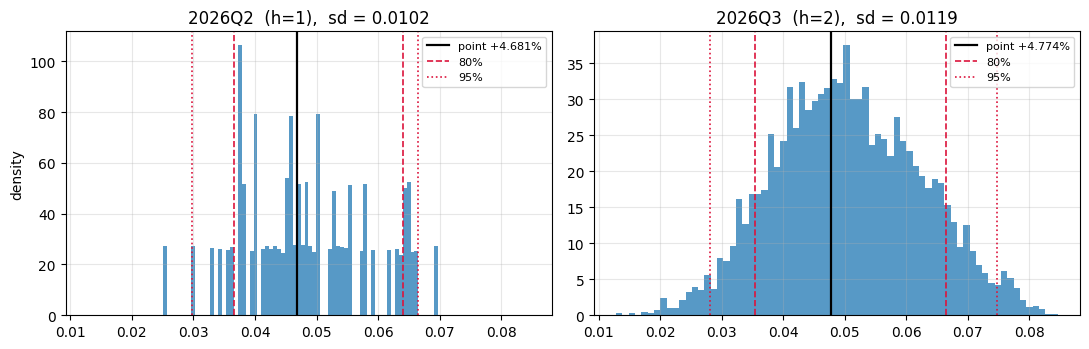

In [17]:
wide = SmoothingRegressionNowcaster().fit(info)
draws_results = wide.predict(info, info.unpublished_quarters(),
                             n_draws=50_000, rng=np.random.default_rng(42))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for ax, r in zip(axes, draws_results):
    ax.hist(r.draws, bins=70, density=True, alpha=0.75)
    ax.axvline(r.point, color="k", lw=1.6, label=f"point {r.point:+.3%}")
    for lo, hi, style, lbl in [(*r.interval_80, "--", "80%"), (*r.interval_95, ":", "95%")]:
        ax.axvline(lo, color="crimson", ls=style, lw=1.2)
        ax.axvline(hi, color="crimson", ls=style, lw=1.2, label=lbl)
    ax.set_title(f"{r.quarter}  (h={r.horizon}),  sd = {r.draw_std:.4f}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
plt.tight_layout()

c1 = float(wide.coefficients["s_lag1"])
ratio = (draws_results[1].draw_std / draws_results[0].draw_std) ** 2
print(f"Var(h=2)/Var(h=1) = {ratio:.4f}   (simulated)")
print(f"analytic 1 + c₁²  = {1 + c1**2:.4f}   <- the recursion reproduces this to")
print(f"                              simulation error ({abs(ratio / (1 + c1**2) - 1):.2%})")

The h=2 interval is ~17 % wider, and *not* because anyone asserted it should be:
for the AR(1) reduced form the recursion generates
$\mathrm{Var}(h{=}2) = \sigma_e^2 (1 + c_1^2)$ endogenously.

### Two things about intervals that will surprise you

**The point forecast is not the centre of its own interval.** Out-of-sample errors
in a small sample have a non-zero mean, and the module *keeps* it — the predictive
distribution answers "where will the realisation fall", and the model's historical
bias is part of that answer. `diagnostics['pool_mean']` records the gap.

**Check `interval_method` before trusting a width.** A `+in_sample_inflated`
suffix means there were fewer than 20 out-of-sample errors, so the interval rests
on in-sample residuals inflated by $\sqrt{1 + p/n}$ — a lower bound on uncertainty.

In [18]:
r = draws_results[0]
print("interval_method :", r.interval_method)
print("residual source :", r.diagnostics["residual_source"])
print("n OOS errors    :", r.diagnostics["n_oos_errors"])
print("pool mean       :", f"{r.diagnostics['pool_mean']:+.6f}",
      "  <- why point != centre of the interval")
print("point           :", f"{r.point:+.6f}")
print("mean of draws   :", f"{r.draw_mean:+.6f}")
print()
print("cross-check — the DIRECT interval at this horizon:")
print("  recursive:", tuple(round(v, 5) for v in r.interval_80))
print("  direct   :", tuple(round(v, 5) for v in r.diagnostics["interval_80_direct"]))
print("  (a materially wider direct interval signals misspecification)")

interval_method : empirical_recursive
residual source : oos
n OOS errors    : 60
pool mean       : +0.001748   <- why point != centre of the interval
point           : +0.046809
mean of draws   : +0.048425

cross-check — the DIRECT interval at this horizon:
  recursive: (0.03653, 0.06413)
  direct   : (0.03733, 0.06413)
  (a materially wider direct interval signals misspecification)


## 7. The evaluation harness — the part that keeps you honest

A nowcast you cannot evaluate is a number you cannot use.
`rolling_origin_evaluation` replays every model quarter by quarter, re-estimating
**everything** at each date — coefficients, scalers, hyperparameters, residual
pools. That is deliberately wasteful; reusing one global fit is exactly the leak
it exists to prevent.

It also *verifies* that hyperparameter selection never saw an evaluation quarter,
rather than trusting it, and raises `NestedSelectionError` if it did.

In [19]:
from private_assets_frequency.nowcast import EvaluationData, rolling_origin_evaluation

eval_data = EvaluationData(
    reported=data["reported"],
    public_factors=data["daily_factors"],
    vintages=data["vintages"],
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    report = rolling_origin_evaluation(
        models={
            "naive": NaiveCarryForward,
            "smoothing_regression": lambda: SmoothingRegressionNowcaster(n_lags=1),
        },
        data=eval_data,
        start="2016Q1",
        end="2026Q1",
        as_of_offsets_days=(0,),
        n_draws=600,
    )

print(report.summary())

Nowcast rolling-origin evaluation
data mode            : vintage  (evaluation_target='first_print')
evaluation dates used: 41 of 43
primary offset       : 0 days after quarter end (grid: (0,))
benchmark            : smoothing_regression

Metrics — subperiod 'full'
----------------------------------------------------------------
               model  horizon  n   rmse    mae  mean_error  directional_hit_rate  coverage_80  coverage_95
smoothing_regression        1 40 0.0116 0.0093      0.0023                0.8500       0.7750       0.9000
               naive        1 40 0.0411 0.0315     -0.0028                   NaN       0.7250       0.9250
smoothing_regression        2 41 0.0125 0.0104      0.0033                0.8780       0.7561       0.9756
               naive        2 41 0.0569 0.0470     -0.0039                   NaN       0.6829       0.8537

Diebold-Mariano vs smoothing_regression
----------------------------------------------------------------
model  horizon  n  rmse_ratio

### How to read that, in the order the numbers tend to mislead

**`mean_error` is the bias, not the error.** Read it next to `coverage_80`: low
RMSE with poor coverage means *overconfident*, which is the failure mode that
matters for risk work.

**A negative DM statistic favours the model in that row.** The p-value uses HAC
(Newey-West) variance with the Harvey-Leybourne-Newbold small-sample correction
and a $t_{n-1}$ reference, because at ~70–100 points the uncorrected test
over-rejects.

**"no significant difference" does not mean equality.** At this sample size the
test has limited power. When a positive claim *is* made, the summary attaches the
multiple-comparison caveat automatically.

**`naive`'s directional hit rate is `NaN`, not 0 %.** A carry-forward predicts no
change, so it never makes a directional call. `directional_coverage` reports how
often a call was made.

**Subperiod rows have tiny `n`.** GFC / COVID / 2022 are 4–8 quarters. Descriptive
only.

In [20]:
full = report.full_sample()
print(full[["model", "horizon", "n", "rmse", "mean_error",
            "directional_hit_rate", "directional_coverage",
            "coverage_80", "coverage_95"]].to_string(index=False))

               model  horizon  n    rmse  mean_error  directional_hit_rate  directional_coverage  coverage_80  coverage_95
smoothing_regression        1 40  0.0116      0.0023                0.8500                1.0000       0.7750       0.9000
               naive        1 40  0.0411     -0.0028                   NaN                0.0000       0.7250       0.9250
smoothing_regression        2 41  0.0125      0.0033                0.8780                1.0000       0.7561       0.9756
               naive        2 41  0.0569     -0.0039                   NaN                0.0000       0.6829       0.8537


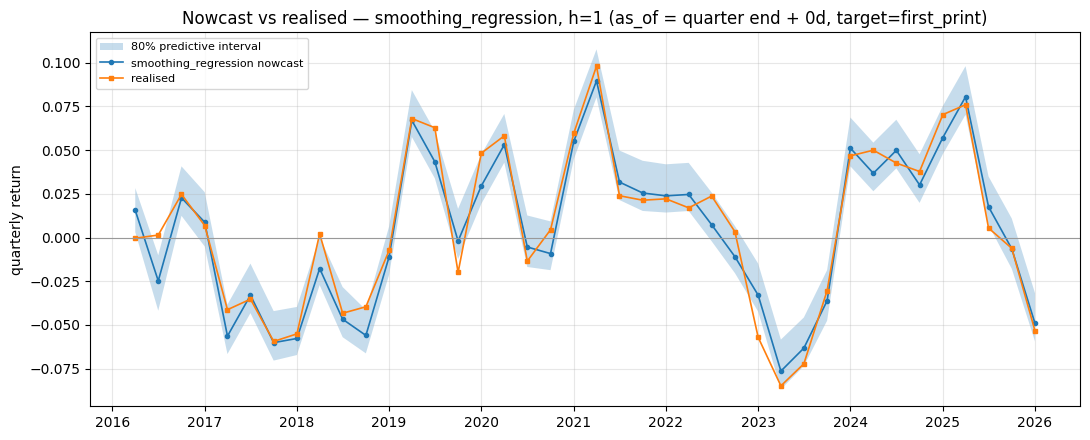

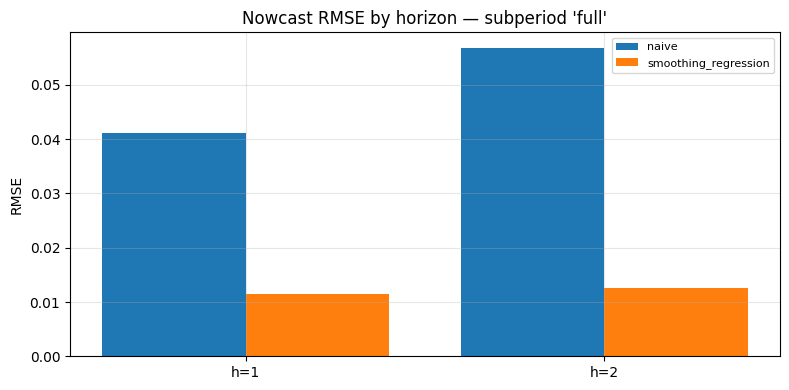

In [21]:
from private_assets_frequency.nowcast.evaluation import (
    plot_error_by_horizon,
    plot_nowcast_vs_realised,
)

plot_nowcast_vs_realised(report, model="smoothing_regression", horizon=1)
plot_error_by_horizon(report)
plt.show()

### Nowcast evolution is event-driven, not continuous

Worth internalising before you configure `as_of_offsets_days`. Once a quarter has
**closed**, no further public data *about that quarter* can arrive — so its
nowcast does not drift with the calendar. What moves it is a **publication
event**: when the previous quarter is released, the target drops from h=2 to h=1
and starts conditioning on a published value instead of a nowcast of one.

In [22]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    evolving = rolling_origin_evaluation(
        models={"smoothing_regression": lambda: SmoothingRegressionNowcaster(n_lags=1)},
        data=eval_data,
        start="2024Q1",
        end="2026Q1",
        as_of_offsets_days=(0, 30, 60),
        n_draws=300,
        benchmark=None,
    )

counts = evolving.rows.groupby("quarter")["as_of"].nunique()
target = counts.loc[counts > 1].index[-1]
track = evolving.evolution(target)
print(f"how the nowcast of {target} moved as information arrived:\n")
print(track[["as_of", "offset_days", "horizon", "point", "actual"]].to_string(index=False))
print()
print("=> the h=2 -> h=1 transition moves it; the 30d and 60d offsets do not,")
print("   because no new data about a CLOSED quarter can arrive.")

how the nowcast of 2026Q1 moved as information arrived:

                        as_of  offset_days  horizon   point  actual
2026-03-31 23:59:59.999999999            0        2 -0.0324 -0.0405
2026-04-30 23:59:59.999999999           30        1 -0.0350 -0.0405
2026-05-30 23:59:59.999999999           60        1 -0.0350 -0.0405

=> the h=2 -> h=1 transition moves it; the 30d and 60d offsets do not,
   because no new data about a CLOSED quarter can arrive.


## 8. Signatures — the challenger model

Everything so far has used the quarter-end compounded factor return $F_Q$. But an
appraiser might not work that way. If they mark against the **average** level over
the quarter, or weight late moves more heavily, then the *path* matters and $F_Q$
throws that information away.

Path signatures are a systematic way to encode a path. For a path
$X:[0,1] \to \mathbb{R}^d$, the level-$k$ term indexed by a word
$(i_1,\dots,i_k)$ is an iterated integral:

$$ S^{(i_1,\dots,i_k)}(X) = \int_{0<u_1<\dots<u_k<1}
   \mathrm{d}X^{i_1}_{u_1}\cdots\mathrm{d}X^{i_k}_{u_k} $$

Two terms carry the intuition, for a path of (time, cumulative factor level):

- $S^{(x)}$ = the total increment — i.e. **the quarter's return**. Level 1 is
  exactly what the smoothing regression already uses.
- $S^{(x,t)} = \int X\,\mathrm{d}s$ = the **average level over the quarter** — a
  genuinely path-dependent statistic that level 1 cannot see.

channels      : ['time', 'equity_market']
path points   : 66 (basepoint + 65 business days)
window        : 2026-04-01 .. 2026-06-30


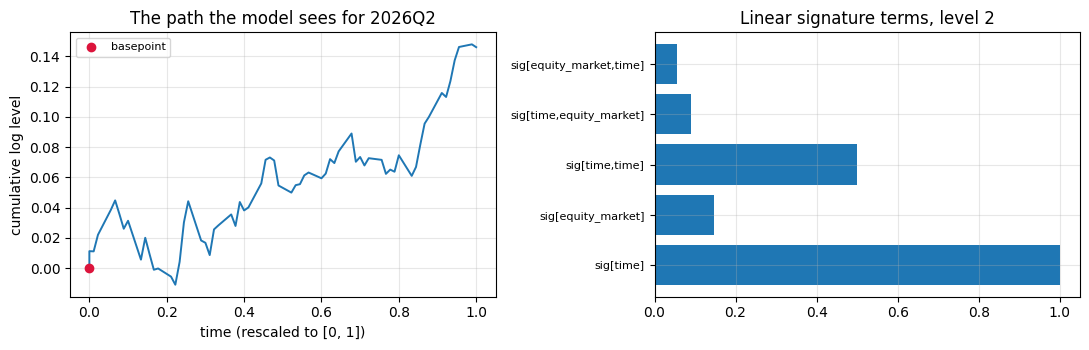

In [23]:
from private_assets_frequency.nowcast.signatures import PathSpec, build_path, path_signature

q2 = pd.Period("2026Q2", freq="Q")
path, channels, pdiag = build_path(info, q2, PathSpec())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(path[:, 0], path[:, 1], lw=1.4)
axes[0].scatter([0], [0], color="crimson", zorder=5, label="basepoint")
axes[0].set_xlabel("time (rescaled to [0, 1])")
axes[0].set_ylabel("cumulative log level")
axes[0].set_title(f"The path the model sees for {q2}")
axes[0].legend(fontsize=8)

feats, names, sdiag = path_signature(info, q2, PathSpec(), level=2)
axes[1].barh(range(len(names)), feats)
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_title("Linear signature terms, level 2")
plt.tight_layout()

print(f"channels      : {channels}")
print(f"path points   : {pdiag['n_path_points']} (basepoint + {pdiag['n_path_observations']} business days)")
print(f"window        : {pdiag['window_start'].date()} .. {pdiag['window_end'].date()}")

### `keep_sigs='linear'` and the nesting theorem

The reference paper's **Theorem 1** says regression on the *linear* signature
terms contains the linear/Kalman predictor as a special case. "Linear" means each
**non-time** channel appears at most once. Time is exempt, because repeated time
indices contribute polynomial-in-time *weights* rather than products of data
increments.

The module makes that nesting **exact**, not asymptotic: at `level=1` with one
factor channel, `SignatureNowcaster` *is* the smoothing regression.

In [24]:
from private_assets_frequency.nowcast.signatures import linear_term_mask, signature_words

words, mask = signature_words(2, 2), linear_term_mask(2, 2)
label = {0: "time", 1: "x"}
for w, keep in zip(words, mask):
    name = ",".join(label[c] for c in w)
    note = ""
    if not keep:
        note = "  <- DROPPED: x appears twice, so this is ½x², not linear in the path"
    elif all(c == 0 for c in w):
        note = "  <- constant (time runs 0->1 on every window), dropped as a regressor"
    print(f"  S({name:<11s}) {'keep' if keep else 'drop'}{note}")

  S(time       ) keep  <- constant (time runs 0->1 on every window), dropped as a regressor
  S(x          ) keep
  S(time,time  ) keep  <- constant (time runs 0->1 on every window), dropped as a regressor
  S(time,x     ) keep
  S(x,time     ) keep
  S(x,x        ) drop  <- DROPPED: x appears twice, so this is ½x², not linear in the path


In [25]:
from private_assets_frequency.nowcast import SignatureNowcaster

# level=1, one factor channel, no regularisation, simple-return levels
nested = SignatureNowcaster(level=1, alpha=0.0, level_channel="simple").fit(info)
nested_results = nested.predict(info, info.unpublished_quarters(),
                                rng=np.random.default_rng(0))

print("signature features :", nested.fit_diagnostics["features"])
print("benchmark features :", model.fit_diagnostics["features"])
print()
for a, b in zip(nested_results, results):
    print(f"  {a.quarter}: signature {a.point:+.12f}   benchmark {b.point:+.12f}   "
          f"diff {a.point - b.point:+.1e}")

signature features : ['intercept', 'sig[equity_market]', 's_lag1']
benchmark features : ['const', 'equity_market', 's_lag1']

  2026Q2: signature +0.046809287736   benchmark +0.046809287736   diff -1.4e-17
  2026Q3: signature +0.047743774747   benchmark +0.047743774747   diff -6.9e-18


### The feature budget — a hard guard, not advice

With ~90 quarterly observations, a model with 30 features is not a model, it is an
interpolation. The budget is `n_features ≤ n_train / 5`, computed from word counts
**before** any signature is built — refused under `FallbackPolicy.STRICT`, skipped
with a warning otherwise.

In [26]:
from private_assets_frequency.nowcast.models.signature import feature_budget

rows = []
for d, lv, keep in [(2, 1, "linear"), (2, 2, "linear"), (2, 2, "all"),
                    (3, 2, "linear"), (4, 2, "linear"), (5, 2, "linear"),
                    (2, 3, "linear"), (3, 3, "linear"), (2, 4, "all")]:
    b = feature_budget(90, n_channels=d, level=lv, keep_sigs=keep)
    rows.append({
        "channels": f"time + {d - 1} factor" + ("s" if d > 2 else ""),
        "level": lv, "keep_sigs": keep,
        "signature_terms": b["n_signature_terms"],
        "n_features": b["n_features"],
        "budget": b["budget"],
        "admissible": b["within_budget"],
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\n(n_train = 90, so the budget is 18 features including s_lag1 and the intercept)")

        channels  level keep_sigs  signature_terms  n_features   budget  admissible
 time + 1 factor      1    linear                1           3  18.0000        True
 time + 1 factor      2    linear                3           5  18.0000        True
 time + 1 factor      2       all                4           6  18.0000        True
time + 2 factors      2    linear                8          10  18.0000        True
time + 3 factors      2    linear               15          17  18.0000        True
time + 4 factors      2    linear               24          26  18.0000       False
 time + 1 factor      3    linear                6           8  18.0000        True
time + 2 factors      3    linear               20          22  18.0000       False
 time + 1 factor      4       all               26          28  18.0000       False

(n_train = 90, so the budget is 18 features including s_lag1 and the intercept)


In [27]:
from private_assets_frequency.core.config import FallbackPolicy
from private_assets_frequency.nowcast.models.signature import FeatureBudgetError

try:
    SignatureNowcaster(level=4, keep_sigs="all", alpha=1e-3,
                       fallback_policy=FallbackPolicy.STRICT).fit(info)
except FeatureBudgetError as exc:
    print("FeatureBudgetError:", " ".join(str(exc).split())[:300], "...")

FeatureBudgetError: signature: 1 of 1 configuration(s) exceed the feature budget n_train/5. The largest needs 28 features against a budget of 20.0 (n_train=100, level=4, keep_sigs='all', channels=2). No configuration is admissible. ...


### Does it actually help? Only when the path matters.

This is the honest test, and the module is built to report it either way. We run
the same comparison on two data sets: one where the appraiser marks against the
quarter-end return, and one where they mark against the average level.

In [28]:
def oos_rmse(dataset, first_origin=70):
    """Rolling-origin out-of-sample RMSE at h=1 for the benchmark and signature models."""
    quarters = pd.PeriodIndex(dataset["reported"].index, freq="Q")
    first_print = (dataset["vintages"].sort_values("release_date")
                   .groupby("quarter")["value"].first())
    errors = {"smoothing_regression": [], "signature_level2": []}
    for o in range(first_origin, len(quarters) - 2):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            i = build_information_set(dataset["reported"], dataset["daily_factors"],
                                      quarters[o + 2].end_time, vintages=dataset["vintages"])
            if i.last_published_quarter != quarters[o]:
                continue
            targets = i.unpublished_quarters()
            for name, factory in [
                ("smoothing_regression", lambda: SmoothingRegressionNowcaster(n_lags=1)),
                ("signature_level2", lambda: SignatureNowcaster(level=2, alpha=1e-3)),
            ]:
                m = factory().fit(i)
                for r in m.predict(i, targets, n_draws=20, rng=np.random.default_rng(0)):
                    if r.horizon == 1:
                        errors[name].append(float(first_print[r.quarter]) - r.point)
    return {k: float(np.sqrt(np.mean(np.square(v)))) for k, v in errors.items()}


closing_mark = oos_rmse(data)
path_data = make_index(path_dependent=True, seed=20261008)
path_mark = oos_rmse(path_data)

summary = pd.DataFrame({
    "appraiser marks against": ["quarter-end return", "average level over quarter"],
    "benchmark RMSE": [closing_mark["smoothing_regression"], path_mark["smoothing_regression"]],
    "signature RMSE": [closing_mark["signature_level2"], path_mark["signature_level2"]],
})
summary["ratio"] = summary["signature RMSE"] / summary["benchmark RMSE"]
print(summary.to_string(index=False))
print()
closing_ratio, path_ratio = summary["ratio"].iloc[0], summary["ratio"].iloc[1]
print(f"=> closing-return mark: ratio {closing_ratio:.3f} "
      f"({'no edge' if closing_ratio > 0.95 else 'edge'}; "
      f"the extra features cost {max(closing_ratio - 1, 0):.1%})")
print(f"=> path-dependent mark: ratio {path_ratio:.3f} "
      f"(RMSE cut by {1 - path_ratio:.0%})")
print()
print("If the signature model does not beat the benchmark on YOUR data, that is")
print("a RESULT, not a failed run. Report it. The evaluation harness says so in")
print("plain words precisely so that outcome is reportable.")

   appraiser marks against  benchmark RMSE  signature RMSE   ratio
        quarter-end return          0.0109          0.0109  1.0020
average level over quarter          0.0114          0.0061  0.5363

=> closing-return mark: ratio 1.002 (no edge; the extra features cost 0.2%)
=> path-dependent mark: ratio 0.536 (RMSE cut by 46%)

If the signature model does not beat the benchmark on YOUR data, that is
a RESULT, not a failed run. Report it. The evaluation harness says so in
plain words precisely so that outcome is reportable.


## 9. Feeding nowcasts to the pipeline

A nowcast is most useful when the rest of the library can use it — so your
monthly and daily upsampled series extend to the present instead of stopping two
quarters back.

Three steps, and one guarantee.

In [29]:
from private_assets_frequency.nowcast import extend_with_nowcasts, to_pipeline_returns

extended = extend_with_nowcasts(info.reported, results)
print(extended.tail(4).to_string())
print()
print("provisional quarters:", [str(q) for q in extended.index[extended["is_provisional"]]])

         value  is_provisional         nowcast_model      as_of  lower_80  upper_80
2025Q4 -0.0598           False                  None        NaT       NaN       NaN
2026Q1 -0.0405           False                  None        NaT       NaN       NaN
2026Q2  0.0468            True  smoothing_regression 2026-10-07    0.0365    0.0641
2026Q3  0.0477            True  smoothing_regression 2026-10-07    0.0354    0.0672

provisional quarters: ['2026Q2', '2026Q3']


The frame is flat, so a provisional number can never be mistaken for a published
one by reading the value alone — the flag, the model, the `as_of` and the interval
all travel with it.

### The guarantee: provisional rows never enter an estimate

`FrequencyPipeline(allow_provisional=True)` fits Stage 1 (desmoothing) and
Stage 2 (the factor model) on **published rows only**, then extends the desmoothed
series across the provisional tail by applying the *fitted* filter. Stages 3–4
upsample the extended series.

The reason is circularity, not tidiness. A nowcast is produced *by* a factor
model; feeding it back as data would shrink the estimated λ and inflate R² for no
informational reason — and the numbers would improve in proportion to how
confident the nowcaster was. Let's verify the estimates are untouched.

In [30]:
from private_assets_frequency.core.config import (
    AssetClassConfig,
    BetaDist,
    InverseGammaPrior,
    NormalPrior,
)
from private_assets_frequency.pipeline.runner import FrequencyPipeline

cfg = AssetClassConfig(
    asset_class="private_equity", smoothing_model="ar1_bayesian",
    native_frequency="quarterly", lambda_prior=BetaDist(2, 2),
    beta_priors={"equity_market": NormalPrior(1.15, 0.5)},
    alpha_prior=NormalPrior(0.0, 0.05), sigma_eps_prior=InverseGammaPrior(3, 0.02),
    default_factors=("equity_market",),
)

# Monthly factors, compounded from the daily panel
monthly = np.expm1(np.log1p(data["daily_factors"])
                   .groupby(pd.PeriodIndex(data["daily_factors"].index, freq="M")).sum())
monthly.index = pd.PeriodIndex(monthly.index, freq="M").to_timestamp(how="end").normalize()


def run(frame, n_months):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return FrequencyPipeline(
            returns=frame,
            factor_returns_monthly=monthly.iloc[:n_months],
            configs={"pe": cfg},
            allow_provisional=bool(frame.attrs["provisional_mask"].to_numpy().any()),
        ).run()


with_prov = run(to_pipeline_returns({"pe": extended}), 3 * len(extended))
only_pub = extended.loc[~extended["is_provisional"]]
without = run(to_pipeline_returns({"pe": only_pub}), 3 * len(only_pub))

a = with_prov.per_strategy["pe"].desmoothed.smoothing_params
b = without.per_strategy["pe"].desmoothed.smoothing_params
print("DESMOOTHING PARAMETERS")
print(f"  with provisional rows : λ = {a['lambda']:.12f}   β = {a['beta']['equity_market']:.12f}")
print(f"  published rows only   : λ = {b['lambda']:.12f}   β = {b['beta']['equity_market']:.12f}")
print(f"  bit-for-bit identical : {a['lambda'] == b['lambda'] and a['beta'] == b['beta']}")
print()
print("MONTHLY OUTPUT")
print(f"  with provisional : {len(with_prov.monthly_returns)} months, "
      f"to {with_prov.monthly_returns.index[-1].date()}")
print(f"  published only   : {len(without.monthly_returns)} months, "
      f"to {without.monthly_returns.index[-1].date()}")
print(f"  gained           : {len(with_prov.monthly_returns) - len(without.monthly_returns)} months "
      "(2 quarters x 3)")

DESMOOTHING PARAMETERS
  with provisional rows : λ = 0.650614901761   β = 1.272554217724
  published rows only   : λ = 0.650614901761   β = 1.272554217724
  bit-for-bit identical : True

MONTHLY OUTPUT
  with provisional : 309 months, to 2026-09-30
  published only   : 303 months, to 2026-03-31
  gained           : 6 months (2 quarters x 3)


provisional months: 6 of 309
estimation window : ('2001Q1', '2026Q1')  <- stops at the last PUBLISHED quarter


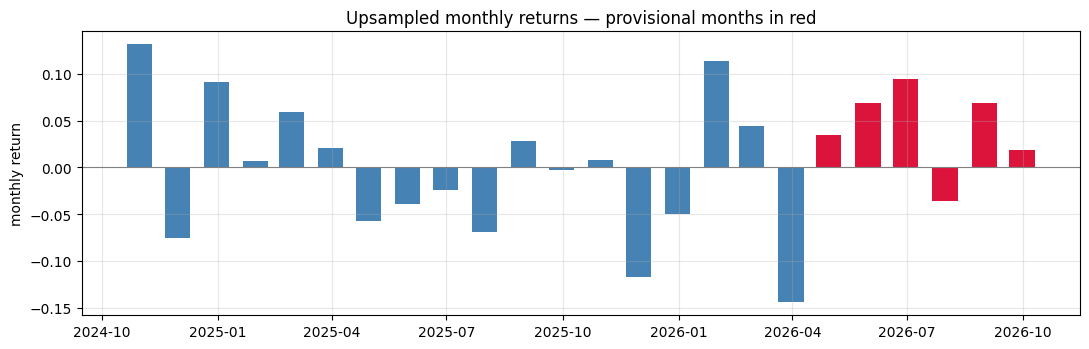

In [31]:
from private_assets_frequency.nowcast import provisional_markers

markers = provisional_markers(with_prov)["pe"]["monthly"]
series = with_prov.monthly_returns["pe"]

fig, ax = plt.subplots(figsize=(11, 3.6))
tail = slice(-24, None)
ax.bar(series.index[tail], series.iloc[tail], width=20,
       color=np.where(markers.iloc[tail], "crimson", "steelblue"))
ax.set_title("Upsampled monthly returns — provisional months in red")
ax.set_ylabel("monthly return")
ax.axhline(0, color="0.5", lw=0.8)
plt.tight_layout()

print("provisional months:", int(markers.sum()), "of", len(markers))
print("estimation window :", with_prov.per_strategy["pe"].disaggregation
      .diagnostics["estimation_window"], " <- stops at the last PUBLISHED quarter")

### Reconciliation — closing the loop

When the official print lands, `reconcile` overwrites the provisional row and
**logs the error**. That log is the honest basis for prediction intervals: errors
from nowcasts actually made at the time, against values actually printed.

In [32]:
from private_assets_frequency.nowcast import reconcile, reconciliation_log

# Pretend January 2027: Q2 and Q3 have now been published (first prints)
first_prints = (data["vintages"].sort_values("release_date")
                .groupby("quarter")["value"].first())
official = first_prints.loc[[pd.Period("2026Q2", freq="Q"), pd.Period("2026Q3", freq="Q")]]

reconciled = reconcile(extended, official)
print(reconciled.tail(3).to_string())
print()
log = reconciliation_log(reconciled)
print("NOWCAST ERROR LOG (feeds future empirical intervals)")
print(log[["quarter", "horizon", "nowcast", "actual", "error", "covered_80"]].to_string(index=False))
print()
print("still provisional:", list(reconciled.index[reconciled["is_provisional"]]), "<- empty: all reconciled")

         value  is_provisional         nowcast_model      as_of  lower_80  upper_80
2026Q1 -0.0405           False                  None        NaT       NaN       NaN
2026Q2  0.0348           False  smoothing_regression 2026-10-07    0.0365    0.0641
2026Q3  0.0381           False  smoothing_regression 2026-10-07    0.0354    0.0672

NOWCAST ERROR LOG (feeds future empirical intervals)
quarter  horizon  nowcast  actual   error  covered_80
 2026Q2        1   0.0468  0.0348 -0.0120       False
 2026Q3        2   0.0477  0.0381 -0.0096        True

still provisional: [] <- empty: all reconciled


Group that log by `nowcast_model` **and** `horizon` before pooling: pooling across
models describes none of them, and pooling across horizons discards the horizon
widening the intervals exist to express.

## 10. Pitfalls — the mistakes this package tries to make hard

### 1. Leakage through the *fitting* path, not the feature path

Everyone remembers not to put $F_{Q+1}$ in the feature vector. Almost nobody
remembers that the **scaler**, the **PCA rotation**, the **hyperparameter choice**,
the **residual pool**, and **borrowed Stage-1 parameters** are all estimated
quantities too — and every one leaks the whole sample if fitted once globally and
reused across evaluation dates. The feature matrix still looks clean.

*Mitigation:* `InformationSet` is the only model input, and everything is re-fitted
from it at every date.

### 2. Validating on revised data

Covered in §3. If you only have the final revised series, the module warns —
believe the warning.

### 3. Selecting hyperparameters on the evaluation sample

With five hyperparameters and ~90 observations, the minimum of many random
variables is *below* the truth by an amount that grows with the number of
configurations tried. Enough to manufacture a "signatures win" result out of pure
noise.

*Mitigation:* selection happens inside `fit(info)` on an inner rolling-origin
split over published quarters only; the harness **verifies** the outer quarter
never entered it. The default grid is deliberately small — only `alpha` is tuned.

### 4. Treating several nowcasts of one quarter as several observations

A grid of `as_of` dates produces several nowcasts of the *same* target. They are
revisions of one estimate, not independent data.

*Mitigation:* headline metrics use a single offset; Diebold-Mariano uses HAC
variance.

### 5. Passing a full-sample `DesmoothedResult` to the structural model

Legitimate for a *production* nowcast at today's `as_of` — there is no later data
to leak. Fatal for a *backtest*.

In [33]:
from private_assets_frequency.nowcast.models.structural import StructuralSmoothingWarning

# Fit Stage 1 on the FULL sample, including unpublished quarters — then backtest
full_obs = data["reported"].copy()
full_obs.index = pd.PeriodIndex(full_obs.index, freq="Q").to_timestamp(how="end")
full_fac = data["quarterly_factors"].loc[pd.PeriodIndex(data["reported"].index, freq="Q")].copy()
full_fac.index = full_obs.index

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    leaky_fit = RudinReparamSmoothing(n_lags=1).fit(full_obs, full_fac, {})
    StructuralSmoothingNowcaster(desmoothed=leaky_fit).fit(info)

for w in caught:
    if issubclass(w.category, StructuralSmoothingWarning):
        print("WARNING:", " ".join(str(w.message).split())[:400], "...")
        break

### A production checklist

```
[ ] Vintage table supplied?            -> otherwise validation is optimistic
[ ] evaluation_target = 'first_print'? -> the default in vintage mode
[ ] interval_method has no
    '+in_sample_inflated' suffix?      -> otherwise <20 OOS errors back the interval
[ ] Does the model beat NaiveCarryForward?  -> if not, use the naive one
[ ] Does the challenger beat the
    smoothing regression?              -> if not, say so; that is a result
[ ] mean_error small vs rmse?           -> otherwise the model is biased
[ ] coverage_80 near 0.80?              -> otherwise it is overconfident
[ ] allow_provisional=True when
    passing provisional rows onward?   -> otherwise they enter the estimates
[ ] λ convention correct if reusing a
    fitted desmoothing model?          -> rolling-annual MUST be declared
```

---

## Where to go next

| Topic | Where |
| --- | --- |
| Full method notes, derivations, all deviations from spec | `docs/nowcast_notes.md` |
| How the module could silently mislead you, and what stops it | `nowcast/DESIGN_NOTES.md` |
| The rest of the pipeline (desmoothing → disaggregation → daily) | `docs/tutorial.ipynb` |
| Signature theory | Cohen et al. (2023), arXiv:2305.10256v3 |

### Summary

1. **The information set is the whole discipline.** Build it with
   `build_information_set`, pass nothing else to a model.
2. **The smoothing regression is the benchmark**, because it is the reduced form
   of the library's own desmoothing models — not a strawman.
3. **Signatures help only when the mark is path-dependent**, and the evaluation
   harness will tell you which case you are in.
4. **Provisional quarters extend a series; they never estimate anything.**
5. **Report the comparison honestly.** "The challenger did not beat the benchmark"
   is a finding, not a failed run.